# Treatment Escalation Following Metformin Initiation in Type 2 Diabetes
## A Descriptive Observational Study Using OMOP CDM Data

**Research Question:** Among adults with T2DM initiating metformin monotherapy, what demographic and clinical characteristics are associated with the *timing* of second-line antidiabetic therapy initiation?

**Study Design:** Descriptive observational study of new metformin users who subsequently initiated second-line antidiabetic therapy. Time to escalation is measured from the metformin index date to the first non-metformin antidiabetic prescription.

**Analytic Layers:**
1. **Descriptive Analysis** — Cohort characteristics, escalation rates, top agents
2. **Survival Analysis** — Kaplan-Meier curves and Cox proportional hazards regression
3. **Stratified Analyses** — By gender, race, ethnicity, age group, CHD, CKD, depression, hypertension
4. **Treatment Pathway Analysis** — Common sequences of therapy following metformin

**Team:** Giselle Feng (fg2618) and Nikhil Anand (na3213)

## 0. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 1. Data Loading and Cleaning

The raw data is at the **drug-exposure level**: each row represents one second-line drug exposure for a patient. A single patient may have multiple rows if they received multiple second-line agents over time.

The cleaning function below:
- Parses dates and standardizes categorical variables
- Standardizes drug names to lowercase for consistency
- Computes derived time variables (time to first escalation, follow-up duration)
- Collapses the data to **one row per patient** using the *first* second-line initiation event
- Creates age group bins for stratified analysis
- Computes censor date as min(cohort_start_date + 270 days, observation_period_end_date)

In [2]:
def clean_and_prepare(filepath):
    """
    Load raw drug-exposure-level data and return two DataFrames:
      1. df_raw  — all exposures within the study window (for pathway analysis)
      2. df      — one row per patient, first escalation event (for survival analysis)
    """

    raw = pd.read_csv(filepath)
    print(f"Raw data: {len(raw)} rows, {raw['person_id'].nunique()} unique patients")

    # --- Parse dates ---
    date_cols = [
        'cohort_start_date', 'cohort_end_date',
        'observation_period_start_date', 'observation_period_end_date',
        'second_line_start_date', 'second_line_end_date', 'censor_date'
    ]
    for col in date_cols:
        raw[col] = pd.to_datetime(raw[col], errors='coerce')

    # --- Drop exposures outside the study window ---
    before = len(raw)
    raw = raw[raw['second_line_start_date'] <= raw['cohort_end_date']].copy()
    dropped = before - len(raw)
    print(f"Dropped {dropped} exposures after study end date (cohort_end_date)")
    print(f"Remaining: {len(raw)} exposures, {raw['person_id'].nunique()} patients")

    # --- Standardize ---
    raw['second_line_drug_name'] = raw['second_line_drug_name'].str.strip().str.lower()
    raw['gender'] = raw['gender'].str.strip().str.upper()
    raw['race'] = raw['race'].str.strip()
    raw['ethnicity'] = raw['ethnicity'].str.strip()

    # --- Days from metformin start to each exposure ---
    raw['days_to_drug'] = (raw['second_line_start_date'] - raw['cohort_start_date']).dt.days

    # --- Flag anomalies ---
    neg = raw[raw['days_to_drug'] < 0]
    if len(neg) > 0:
        print(f"WARNING: {len(neg)} exposures with negative time. Removing.")
        raw = raw[raw['days_to_drug'] >= 0].copy()

    same_day = raw[raw['days_to_drug'] == 0]
    if len(same_day) > 0:
        print(f"NOTE: {len(same_day)} exposures on day 0 (same day as metformin start).")

    # --- Study period length ---
    raw['study_period_days'] = (raw['cohort_end_date'] - raw['cohort_start_date']).dt.days
    print(f"Study period: {raw['study_period_days'].iloc[0]} days "
          f"({raw['cohort_start_date'].iloc[0].date()} to {raw['cohort_end_date'].iloc[0].date()})")

    # --- Save cleaned full dataset for pathway analysis ---
    df_raw = raw.copy()

    # --- Collapse to one row per patient: first second-line event ---
    raw = raw.sort_values(['person_id', 'second_line_start_date'])
    df = raw.groupby('person_id').first().reset_index()

    # --- Time to first escalation ---
    df['time_to_escalation'] = (df['second_line_start_date'] - df['cohort_start_date']).dt.days

    # --- Event indicator (all = 1, everyone escalated) ---
    df['event'] = 1

    # --- Age groups ---
    df['age_group'] = pd.cut(
        df['age_at_index'],
        bins=[17, 44, 64, 74, 120],
        labels=['18-44', '45-64', '65-74', '75+']
    )

    # --- Rename flags ---
    df = df.rename(columns={
        'hypertension_flag': 'hypertension',
        'depression_flag': 'depression',
        'chd_flag': 'chd',
        'ckd_flag': 'ckd'
    })
    df_raw = df_raw.rename(columns={
        'hypertension_flag': 'hypertension',
        'depression_flag': 'depression',
        'chd_flag': 'chd',
        'ckd_flag': 'ckd'
    })

    # --- Flag same-day escalators (likely combination initiators) ---
    df['same_day_escalation'] = (df['time_to_escalation'] == 0).astype(int)
    n_sameday = df['same_day_escalation'].sum()
    pct_sameday = n_sameday / len(df) * 100
    print(f"\n  Same-day escalators (day 0): {n_sameday} ({pct_sameday:.1f}%)")
    print(f"    → likely combination initiators, predominantly sulfonylureas")
    print(f"  Sequential escalators (day >0): {(df['same_day_escalation']==0).sum()}")

    print(f"\nPatient-level data: {len(df)} patients")
    print(f"  Median time to escalation: {df['time_to_escalation'].median():.0f} days")
    print(f"  Range: {df['time_to_escalation'].min()} – {df['time_to_escalation'].max()} days")

    return df_raw, df


df_raw, df = clean_and_prepare('../Data/cohort_raw.csv')

# ── Cohort split: sequential escalators vs same-day combination initiators ──
df_sequential = df[df['time_to_escalation'] > 0].copy()   # primary analysis cohort
df_sameday    = df[df['time_to_escalation'] == 0].copy()  # sensitivity / descriptive only

print(f"\n{'='*55}")
print(f"COHORT SPLIT")
print(f"{'='*55}")
print(f"  Combination initiators (day 0):  n={len(df_sameday):>5}  ({len(df_sameday)/len(df)*100:.1f}%)")
print(f"  Sequential escalators  (day >0): n={len(df_sequential):>5}  ({len(df_sequential)/len(df)*100:.1f}%)")
print(f"\nAll downstream analyses use df_sequential (n={len(df_sequential)}).")

Raw data: 25182 rows, 9951 unique patients
Dropped 8419 exposures after study end date (cohort_end_date)
Remaining: 16763 exposures, 9116 patients
NOTE: 1867 exposures on day 0 (same day as metformin start).
Study period: 334 days (2009-01-15 to 2009-12-15)

  Same-day escalators (day 0): 1860 (20.4%)
    → likely combination initiators, predominantly sulfonylureas
  Sequential escalators (day >0): 7256

Patient-level data: 9116 patients
  Median time to escalation: 67 days
  Range: 0 – 334 days

COHORT SPLIT
  Combination initiators (day 0):  n= 1860  (20.4%)
  Sequential escalators  (day >0): n= 7256  (79.6%)

All downstream analyses use df_sequential (n=7256).


---
## Layer 1: Descriptive Analysis

### 1.1 Table 1 — Baseline Characteristics

Standard summary of cohort demographics and comorbidities, reported as counts and percentages for categorical variables, and median (IQR) for continuous variables.

In [3]:
def make_table1(df):
    """Generate a Table 1 of baseline characteristics."""

    rows = []
    N = len(df)

    # --- Continuous: Age ---
    med = df["age_at_index"].median()
    q1 = df["age_at_index"].quantile(0.25)
    q3 = df["age_at_index"].quantile(0.75)
    rows.append(("Median Age at Index (IQR)", f"{med:.0f} ({q1:.0f}–{q3:.0f})", ""))

    # --- Continuous: Time to escalation ---
    med_t = df["time_to_escalation"].median()
    q1_t = df["time_to_escalation"].quantile(0.25)
    q3_t = df["time_to_escalation"].quantile(0.75)
    rows.append(
        (
            "Time to escalation (days), median (IQR)",
            f"{med_t:.0f} ({q1_t:.0f}–{q3_t:.0f})",
            "",
        )
    )

    rows.append(("", "", ""))  # spacer

    # --- Categorical variables ---
    cat_vars = {
        "Gender": "gender",
        "Race": "race",
        "Ethnicity": "ethnicity",
        "Age group": "age_group",
    }
    for label, col in cat_vars.items():
        rows.append((f"**{label}**", "n", "%"))
        for val in sorted(df[col].dropna().unique()):
            n = (df[col] == val).sum()
            pct = n / N * 100
            rows.append((f"  {val}", str(n), f"{pct:.1f}%"))

    # --- Binary comorbidity flags ---
    rows.append(("", "", ""))
    rows.append(("**Comorbidities**", "n", "%"))
    for label, col in [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ]:
        n = df[col].sum()
        pct = n / N * 100
        rows.append((f"  {label}", str(int(n)), f"{pct:.1f}%"))

    # --- Comorbidity count ---
    df_temp = df.copy()
    df_temp["comorbidity_count"] = df_temp[
        ["hypertension", "depression", "chd", "ckd"]
    ].sum(axis=1)
    med_c = df_temp["comorbidity_count"].median()
    mean_c = df_temp["comorbidity_count"].mean()
    rows.append(
        (f"Comorbidity count (of 4), median (mean)", f"{med_c:.0f} ({mean_c:.1f})", "")
    )

    table1 = pd.DataFrame(rows, columns=["Characteristic", "Value", ""])
    return table1


table1 = make_table1(df)
print("TABLE 1: Baseline Characteristics")
print("=" * 60)
print(table1.to_string(index=False))

TABLE 1: Baseline Characteristics
                         Characteristic      Value       
              Median Age at Index (IQR) 74 (67–82)       
Time to escalation (days), median (IQR) 67 (9–158)       
                                                         
                             **Gender**          n      %
                                 FEMALE       5637  61.8%
                                   MALE       3479  38.2%
                               **Race**          n      %
              Black or African American       1120  12.3%
                                  White       7996  87.7%
                          **Ethnicity**          n      %
                 Not Hispanic or Latino       9116 100.0%
                          **Age group**          n      %
                                  18-44        404   4.4%
                                  45-64       1388  15.2%
                                  65-74       2974  32.6%
                                    75

### 1.2 Top Second-Line Agents

Distribution of the first second-line antidiabetic agent initiated after metformin.

First second-line agent initiated after metformin:
---------------------------------------------
  glyburide             n=3754  (41.2%)
  glipizide             n=2447  (26.8%)
  rosiglitazone         n=1037  (11.4%)
  glimepiride           n=710  (7.8%)
  pioglitazone          n=664  (7.3%)
  sitagliptin           n=272  (3.0%)
  repaglinide           n=129  (1.4%)
  nateglinide           n= 69  (0.8%)
  insulin glargine      n= 24  (0.3%)
  insulin detemir       n=  8  (0.1%)
  saxagliptin           n=  2  (0.0%)
                      N=9116


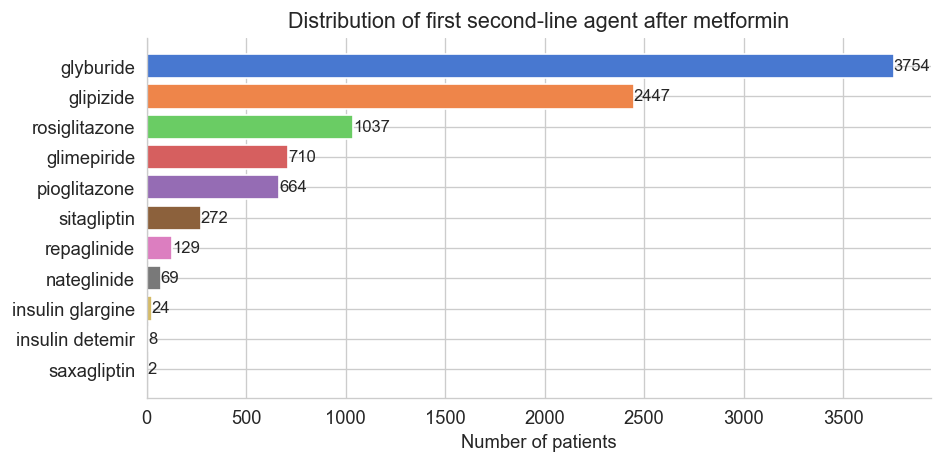

In [4]:
# Top second-line agents (first agent per patient)
drug_counts = df["second_line_drug_name"].value_counts()
drug_pcts = (drug_counts / len(df) * 100).round(1)

print("First second-line agent initiated after metformin:")
print("-" * 45)
for drug, n in drug_counts.items():
    print(f"  {drug:<20s}  n={n:>3d}  ({drug_pcts[drug]:.1f}%)")
print(f"{'':20s}  N={drug_counts.sum():>3d}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("muted", len(drug_counts))
bars = ax.barh(
    drug_counts.index[::-1],
    drug_counts.values[::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Number of patients")
ax.set_title("Distribution of first second-line agent after metformin")
for bar, val in zip(bars, drug_counts.values[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=10,
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 1.3 Distribution of Time to Escalation

Histogram and descriptive statistics for the primary outcome: days from metformin initiation to first second-line drug.

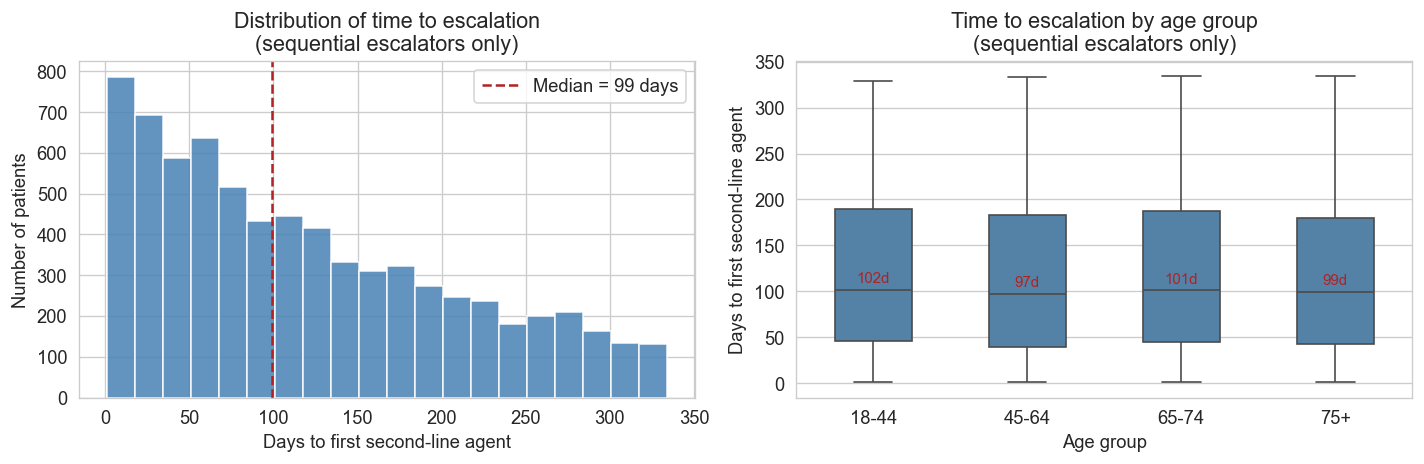


Descriptive statistics — Time to escalation (days), sequential escalators:
count    7256.0
mean      119.0
std        89.4
min         1.0
25%        43.0
50%        99.0
75%       183.0
max       334.0
Name: time_to_escalation, dtype: float64

By age group:
            count   mean   std  min   25%    50%    75%    max
age_group                                                     
18-44       307.0  121.0  91.3  1.0  45.5  102.0  189.5  329.0
45-64      1110.0  118.4  89.4  1.0  40.0   97.0  182.8  333.0
65-74      2421.0  120.3  90.0  1.0  45.0  101.0  187.0  334.0
75+        3418.0  118.2  88.8  1.0  43.0   99.0  180.0  334.0


In [6]:
# Note: All plots below use df_sequential (sequential escalators only, day > 0)
# Same-day escalators (n=1,860) are described separately — they represent
# intentional combination therapy at diagnosis, not true escalation events.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(
    df_sequential["time_to_escalation"], bins=20, color="steelblue", edgecolor="white", alpha=0.85
)
axes[0].axvline(
    df_sequential["time_to_escalation"].median(),
    color="firebrick",
    linestyle="--",
    label=f"Median = {df_sequential['time_to_escalation'].median():.0f} days",
)
axes[0].set_xlabel("Days to first second-line agent")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Distribution of time to escalation\n(sequential escalators only)")
axes[0].legend()

# Box plot by age group — seaborn handles Categorical dtype correctly
sns.boxplot(
    data=df_sequential,
    x="age_group",
    y="time_to_escalation",
    order=["18-44", "45-64", "65-74", "75+"],
    color="steelblue",
    width=0.5,
    ax=axes[1],
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
)
# Overlay median labels
for i, grp in enumerate(["18-44", "45-64", "65-74", "75+"]):
    med = df_sequential[df_sequential["age_group"] == grp]["time_to_escalation"].median()
    axes[1].text(i, med + 8, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Days to first second-line agent")
axes[1].set_title("Time to escalation by age group\n(sequential escalators only)")

plt.tight_layout()
plt.show()

# Summary stats by age group
print("\nDescriptive statistics — Time to escalation (days), sequential escalators:")
print(df_sequential["time_to_escalation"].describe().round(1))
print("\nBy age group:")
print(df_sequential.groupby("age_group", observed=True)["time_to_escalation"]
      .describe().round(1))

### 1.4 Comorbidity Co-occurrence

Cross-tabulation of baseline comorbidities to understand burden and co-occurrence patterns.

Comorbidity count distribution:
comorbidity_count
0     860
1    1983
2    3078
3    2798
4     397
Name: count, dtype: int64

Comorbidity co-occurrence matrix (counts):
              hypertension  depression   chd   ckd
hypertension           870         557   797   593
depression             557        4655  4276  3036
chd                    797        4276  7596  4595
ckd                    593        3036  4595  5000


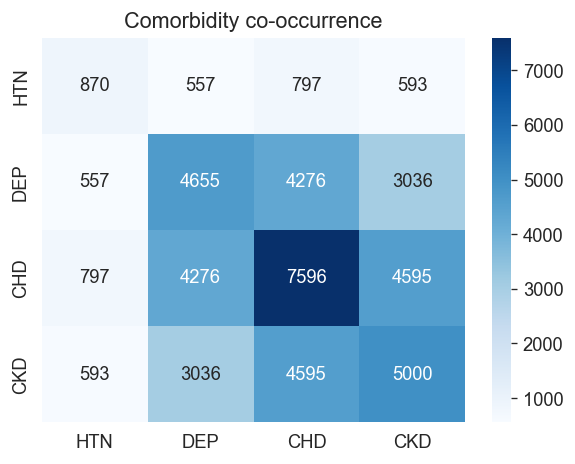

In [7]:
comorbidity_cols = ["hypertension", "depression", "chd", "ckd"]

# Comorbidity count distribution
df["comorbidity_count"] = df[comorbidity_cols].sum(axis=1)
print("Comorbidity count distribution:")
print(df["comorbidity_count"].value_counts().sort_index())
print()

# Co-occurrence matrix
co_matrix = pd.DataFrame(index=comorbidity_cols, columns=comorbidity_cols, dtype=float)
for c1 in comorbidity_cols:
    for c2 in comorbidity_cols:
        if c1 == c2:
            co_matrix.loc[c1, c2] = df[c1].sum()
        else:
            co_matrix.loc[c1, c2] = ((df[c1] == 1) & (df[c2] == 1)).sum()

print("Comorbidity co-occurrence matrix (counts):")
print(co_matrix.astype(int))

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    co_matrix.astype(int),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["HTN", "DEP", "CHD", "CKD"],
    yticklabels=["HTN", "DEP", "CHD", "CKD"],
)
ax.set_title("Comorbidity co-occurrence")
plt.tight_layout()
plt.show()

### 1.5 Time to Escalation by Comorbidity Status

Comparing median escalation times across comorbidity subgroups to identify preliminary patterns before formal modeling.

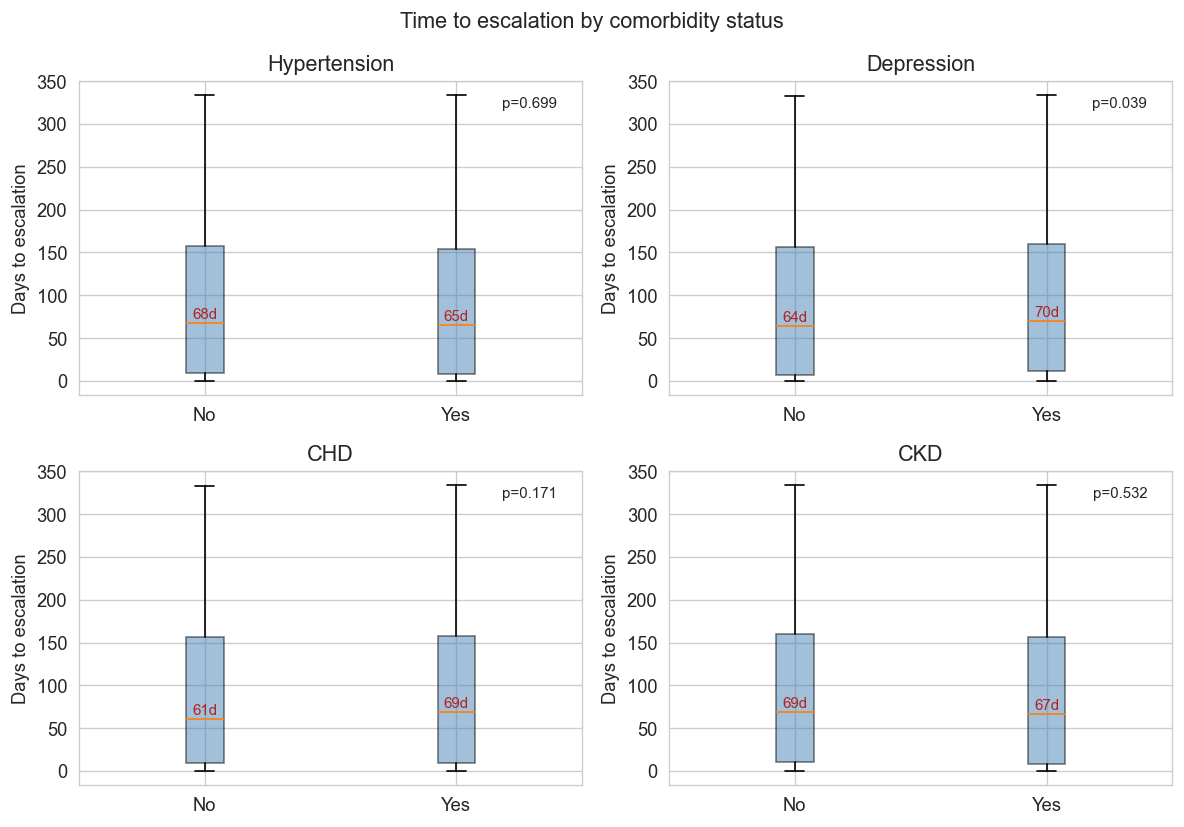

In [168]:
from scipy.stats import mannwhitneyu

comorbidity_vars = [
    ('Hypertension', 'hypertension'),
    ('Depression',   'depression'),
    ('CHD',          'chd'),
    ('CKD',          'ckd'),
]

n_tests = len(comorbidity_vars)
bonferroni_alpha = 0.05 / n_tests  # 0.0125

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, (label, col) in zip(axes.ravel(), comorbidity_vars):
    data_0 = df_sequential[df_sequential[col] == 0]['time_to_escalation']
    data_1 = df_sequential[df_sequential[col] == 1]['time_to_escalation']

    ax.boxplot([data_0, data_1], labels=['No', 'Yes'], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(label)
    ax.set_ylabel('Days to escalation')

    # Median labels
    for i, data in enumerate([data_0, data_1]):
        med = data.median()
        ax.text(i + 1, med + 5, f'{med:.0f}d', ha='center', fontsize=9, color='firebrick')

    # Mann-Whitney + Bonferroni + rank-biserial effect size
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = mannwhitneyu(data_0, data_1, alternative='two-sided')
        n0, n1 = len(data_0), len(data_1)
        rbc = 1 - (2 * stat) / (n0 * n1)  # rank-biserial correlation

        if p < bonferroni_alpha:
            sig_label = f'p={p:.3f} * (Bonferroni sig.)'
            color = 'red'
        else:
            sig_label = f'p={p:.3f} (ns)'
            color = 'gray'

        ax.text(0.97, 0.97,
                f'{sig_label}\nEffect size r={rbc:.3f}\nn(No)={n0}, n(Yes)={n1}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8, color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

plt.suptitle(
    f'Time to escalation by comorbidity status\n'
    f'(sequential escalators only; Bonferroni-corrected \u03b1={bonferroni_alpha:.4f})',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Summary table
print(f"\nBonferroni-corrected \u03b1 threshold: {bonferroni_alpha:.4f}\n")
print(f"{'Comorbidity':<15} {'p-value':>10} {'Significant?':>15} {'Effect r':>10} {'n(No)':>7} {'n(Yes)':>7}")
print('-' * 70)
for label, col in comorbidity_vars:
    d0 = df_sequential[df_sequential[col] == 0]['time_to_escalation']
    d1 = df_sequential[df_sequential[col] == 1]['time_to_escalation']
    s, p = mannwhitneyu(d0, d1, alternative='two-sided')
    rbc = 1 - (2 * s) / (len(d0) * len(d1))
    sig = 'YES *' if p < bonferroni_alpha else 'no'
    print(f"{label:<15} {p:>10.3f} {sig:>15} {rbc:>10.3f} {len(d0):>7} {len(d1):>7}")

---
## Layer 2: Survival Analysis

### 2.1 Overall Kaplan-Meier Curve

Since all patients in this dataset were escalated (event = 1 for all), the KM curve shows the cumulative proportion who have been escalated over time. There are no censored observations.

**Limitation:** This dataset includes only patients who *were* escalated. Patients who remained on metformin monotherapy throughout the observation period are excluded. The KM curve therefore represents the distribution of escalation timing conditional on escalation occurring, not the overall probability of escalation in the full cohort.

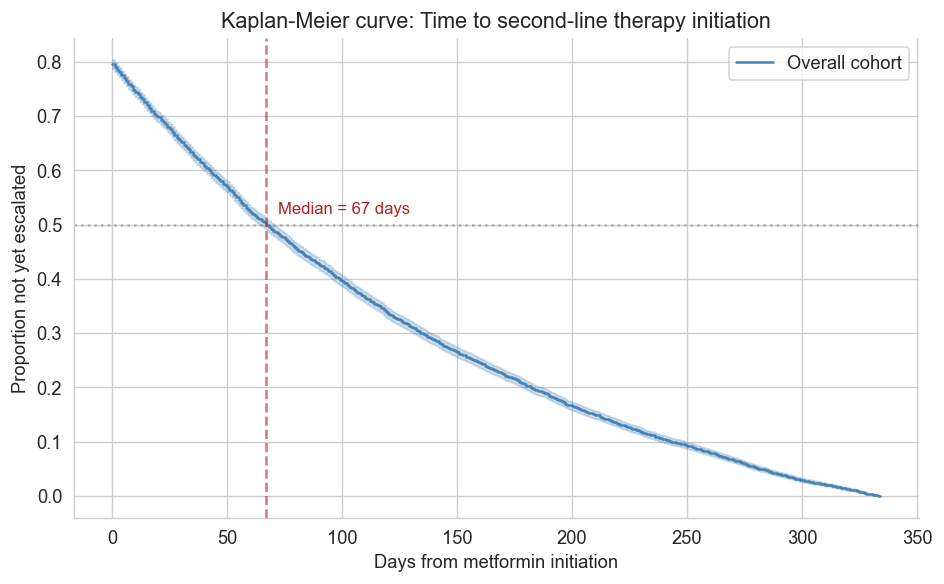

Median time to escalation: 67 days
Mean time to escalation: 94.7 days


In [8]:
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(8, 5))

kmf.fit(df["time_to_escalation"], event_observed=df["event"], label="Overall cohort")
kmf.plot_survival_function(ax=ax, ci_show=True, color="steelblue")

ax.set_xlabel("Days from metformin initiation")
ax.set_ylabel("Proportion not yet escalated")
ax.set_title("Kaplan-Meier curve: Time to second-line therapy initiation")
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)

median_surv = kmf.median_survival_time_
ax.axvline(x=median_surv, color="firebrick", linestyle="--", alpha=0.6)
ax.text(
    median_surv + 5,
    0.52,
    f"Median = {median_surv:.0f} days",
    color="firebrick",
    fontsize=10,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median time to escalation: {median_surv:.0f} days")
print(f"Mean time to escalation: {df['time_to_escalation'].mean():.1f} days")

### 2.2 Kaplan-Meier Curves — Stratified

KM curves stratified by each demographic and clinical characteristic, with log-rank tests for group differences.

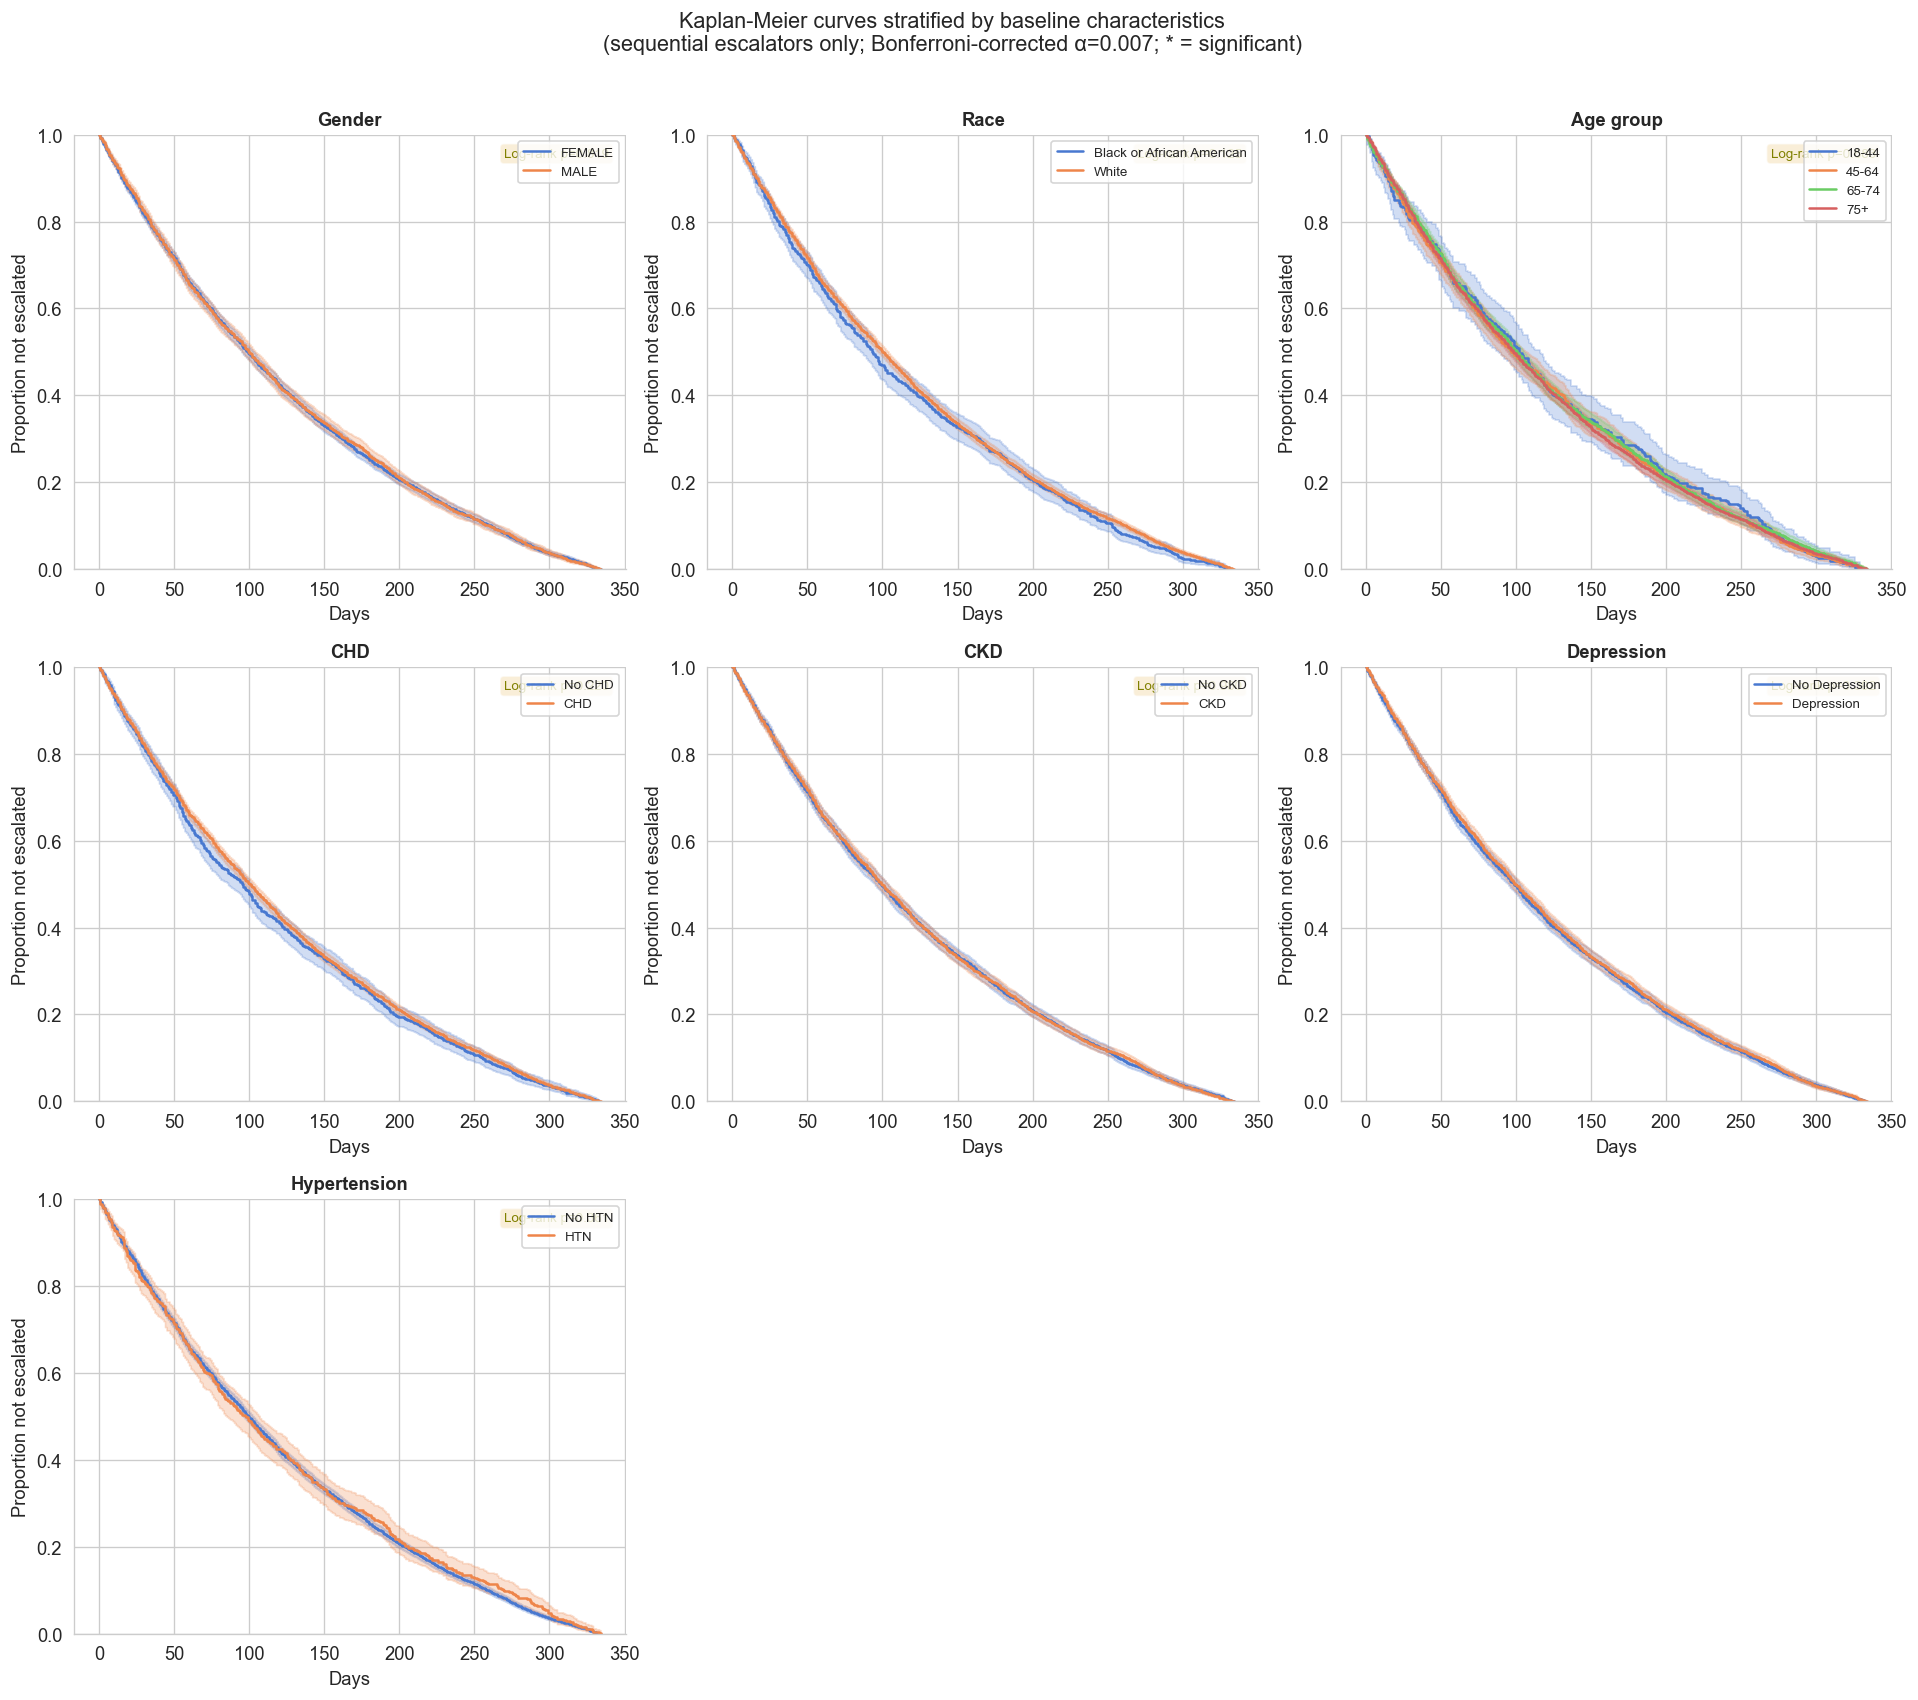


Variable           p-value    Significant (p<0.007)?
-------------------------------------------------------
Gender               0.819                        no
Race                 0.125                        no
Age group            0.683                        no
CHD                  0.220                        no
CKD                  0.980                        no
Depression           0.392                        no
Hypertension         0.361                        no


In [9]:
strat_vars = [
    ('Gender',       'gender',      None),
    ('Race',         'race',        None),
    ('Age group',    'age_group',   ['18-44', '45-64', '65-74', '75+']),
    ('CHD',          'chd',         {0: 'No CHD',        1: 'CHD'}),
    ('CKD',          'ckd',         {0: 'No CKD',        1: 'CKD'}),
    ('Depression',   'depression',  {0: 'No Depression', 1: 'Depression'}),
    ('Hypertension', 'hypertension',{0: 'No HTN',        1: 'HTN'}),
]

n_tests = len(strat_vars)
bonferroni_alpha = 0.05 / n_tests  # 0.007

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()
kmf = KaplanMeierFitter()

logrank_results = []

for idx, (title, col, label_map) in enumerate(strat_vars):
    ax = axes[idx]

    # Build a display-label column for this variable
    if isinstance(label_map, dict):
        df_sequential[f'_label_{col}'] = df_sequential[col].map(label_map)
        group_col = f'_label_{col}'
        ordered_groups = list(label_map.values())
    elif isinstance(label_map, list):
        group_col = col
        ordered_groups = label_map
    else:
        group_col = col
        ordered_groups = sorted(df_sequential[col].dropna().unique(), key=str)

    palette = sns.color_palette('muted', len(ordered_groups))

    for i, grp in enumerate(ordered_groups):
        mask = df_sequential[group_col] == grp
        if mask.sum() < 2:
            continue
        kmf.fit(
            df_sequential.loc[mask, 'time_to_escalation'],
            event_observed=df_sequential.loc[mask, 'event'],
            label=str(grp)
        )
        kmf.plot_survival_function(ax=ax, ci_show=True, color=palette[i])

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Proportion not escalated')
    ax.set_ylim(0, 1)  # force y-axis to start at 0 and top at 1
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Log-rank test on original (non-label) column
    valid_mask = df_sequential[col].notna()
    valid_groups = [g for g in df_sequential[col].dropna().unique()
                    if (df_sequential[col] == g).sum() >= 2]
    if len(valid_groups) >= 2:
        try:
            sub = df_sequential[df_sequential[col].isin(valid_groups)]
            result = multivariate_logrank_test(
                sub['time_to_escalation'], sub[col], sub['event']
            )
            p = result.p_value
            logrank_results.append((title, p))
            sig = p < bonferroni_alpha
            color = 'red' if sig else 'olive'
            label_text = f'Log-rank p={p:.3f}'
            if sig:
                label_text += ' *'
            ax.text(0.97, 0.97, label_text,
                    transform=ax.transAxes, ha='right', va='top', fontsize=8, color=color,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
        except Exception:
            pass

# Hide unused subplots
for idx in range(len(strat_vars), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    f'Kaplan-Meier curves stratified by baseline characteristics\n'
    f'(sequential escalators only; Bonferroni-corrected \u03b1={bonferroni_alpha:.3f}; * = significant)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Variable':<15} {'p-value':>10} {'Significant (p<{:.3f})?'.format(bonferroni_alpha):>25}")
print('-' * 55)
for title, p in logrank_results:
    sig = 'YES *' if p < bonferroni_alpha else 'no'
    print(f"{title:<15} {p:>10.3f} {sig:>25}")

### 2.3 Cox Proportional Hazards Model

A multivariable Cox regression to identify characteristics independently associated with the hazard (rate) of second-line therapy initiation. 

**Interpretation:** A hazard ratio > 1 means faster escalation (shorter time to second-line therapy). A hazard ratio < 1 means slower escalation.

Covariates: age (continuous), gender, race, CHD, CKD, depression, hypertension.

In [10]:
# Prepare data for Cox regression
cox_df = df[
    [
        "time_to_escalation",
        "event",
        "age_at_index",
        "gender",
        "race",
        "chd",
        "ckd",
        "depression",
        "hypertension",
    ]
].copy()

# Encode gender: FEMALE = 0, MALE = 1
cox_df["male"] = (cox_df["gender"] == "MALE").astype(int)

# Encode race: dummies with White as reference
race_dummies = pd.get_dummies(cox_df["race"], prefix="race", drop_first=False)
# Use White as reference if present
if "race_White" in race_dummies.columns:
    race_dummies = race_dummies.drop(columns=["race_White"])
else:
    race_dummies = race_dummies.iloc[:, 1:]  # drop first alphabetically

cox_df = pd.concat([cox_df, race_dummies], axis=1)
cox_df = cox_df.drop(columns=["gender", "race"])

# Rename for readability
cox_df.columns = [c.replace("race_", "race: ") for c in cox_df.columns]

print("Cox model input shape:", cox_df.shape)
print("\nVariable summary:")
print(cox_df.describe().T[["mean", "std", "min", "max"]].round(2))

Cox model input shape: (9116, 9)

Variable summary:
                     mean    std   min    max
time_to_escalation  94.74  93.05   0.0  334.0
event                1.00   0.00   1.0    1.0
age_at_index        72.68  13.76  26.0  100.0
chd                  0.83   0.37   0.0    1.0
ckd                  0.55   0.50   0.0    1.0
depression           0.51   0.50   0.0    1.0
hypertension         0.10   0.29   0.0    1.0
male                 0.38   0.49   0.0    1.0


In [14]:
# Fit Cox PH model
cph = CoxPHFitter()
cph.fit(cox_df, 
        duration_col='time_to_escalation', 
        event_col='event',
        strata=['hypertension']) 

print("\n" + "=" * 70)
print("COX PROPORTIONAL HAZARDS MODEL — RESULTS")
print("=" * 70)
cph.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%'])


COX PROPORTIONAL HAZARDS MODEL — RESULTS


<lifelines.CoxPHFitter: fitted with 9116 total observations, 0 right-censored observations>
             duration col = 'time_to_escalation'
                event col = 'event'
                   strata = hypertension
      baseline estimation = breslow
   number of observations = 9116
number of events observed = 9116
   partial log-likelihood = -71136.76
         time fit was run = 2026-04-19 19:46:05 UTC

---
                                 coef exp(coef)  se(coef) exp(coef) lower 95% exp(coef) upper 95%    p
covariate                                                                                             
age_at_index                     0.00      1.00      0.00                1.00                1.00 0.47
chd                             -0.04      0.96      0.03                0.91                1.02 0.22
ckd                              0.03      1.03      0.02                0.98                1.07 0.24
depression                      -0.03      0.97      0.02                0.93                1.01 0.11
male                             0.01      1.01      0.02                0.97                1.05 0.75
race: Black or African American  0.04      1.04      0.03                0.98                1.11 0.17
---
Concordance = 0.51
Partial AIC = 142285.52
log-likelihood ratio test = 7.46 on 6 df
-log2(p) of ll-ratio test = 1.84

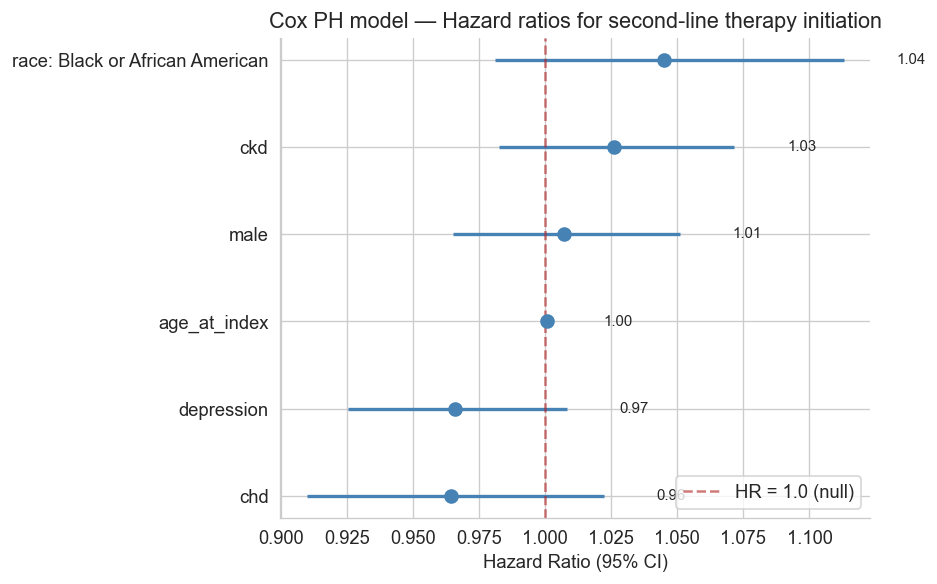

In [15]:
# Forest plot of hazard ratios
fig, ax = plt.subplots(figsize=(8, 5))

summary = cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']].copy()
summary = summary.sort_values('exp(coef)')

y_pos = range(len(summary))
ax.hlines(y_pos, summary['exp(coef) lower 95%'], summary['exp(coef) upper 95%'],
          color='steelblue', linewidth=2)
ax.scatter(summary['exp(coef)'], y_pos, color='steelblue', s=60, zorder=3)
ax.axvline(x=1.0, color='firebrick', linestyle='--', alpha=0.6, label='HR = 1.0 (null)')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Cox PH model — Hazard ratios for second-line therapy initiation')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower right')

# Add HR labels
for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(row['exp(coef) upper 95%'] + 0.02, i,
            f"{row['exp(coef)']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 2.4 Cox Model Diagnostics

Checking the proportional hazards assumption via Schoenfeld residual tests. A significant p-value (< 0.05) suggests the proportional hazards assumption may be violated for that covariate.

In [16]:
# Proportional hazards test
print("Proportional Hazards Assumption Test (Schoenfeld residuals)")
print("=" * 60)
try:
    ph_test = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"PH test result: {e}")
    print("\nNote: With a small sample (N=~50) and no censoring, these tests have")
    print("limited power. Interpret with caution.")

Proportional Hazards Assumption Test (Schoenfeld residuals)
Proportional hazard assumption looks okay.


---
## Layer 3: Stratified Cox Models

Running separate Cox models within demographic and clinical subgroups to examine whether the effect of covariates on escalation timing varies across strata. 

For binary stratification variables, we compare HRs across strata; for multi-level variables (age group, race), we describe covariate effects within each stratum.

In [175]:
def run_stratified_cox(df, strat_col, strat_label, covariate_cols):
    """
    Run Cox PH model within each stratum of strat_col.
    Returns a summary DataFrame of HRs across strata.
    """
    results = []
    strata = sorted(df[strat_col].dropna().unique(), key=lambda x: str(x))
    
    for stratum in strata:
        subset = df[df[strat_col] == stratum].copy()
        if len(subset) < 10:
            print(f"  Skipping {strat_label}={stratum}: n={len(subset)} (too few)")
            continue
        
        # Select covariates that have variance in this subset
        valid_covs = []
        for c in covariate_cols:
            if c in subset.columns and subset[c].nunique() > 1:
                valid_covs.append(c)
        
        if len(valid_covs) == 0:
            print(f"  Skipping {strat_label}={stratum}: no valid covariates with variance")
            continue
        
        model_df = subset[['time_to_escalation', 'event'] + valid_covs].dropna()
        
        if len(model_df) < 10:
            continue
        
        try:
            cph_s = CoxPHFitter(penalizer=0.1)  # light regularization for small strata
            cph_s.fit(model_df, duration_col='time_to_escalation', event_col='event')
            
            for cov in valid_covs:
                hr = cph_s.hazard_ratios_[cov]
                ci_low = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[0])
                ci_high = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[1])
                p = cph_s.summary.loc[cov, 'p']
                results.append({
                    'Stratum': f'{strat_label}={stratum}',
                    'N': len(model_df),
                    'Covariate': cov,
                    'HR': hr,
                    'CI_low': ci_low,
                    'CI_high': ci_high,
                    'p': p
                })
        except Exception as e:
            print(f"  {strat_label}={stratum}: model failed ({e})")
    
    return pd.DataFrame(results)


# Core covariates for stratified models
base_covs = ['age_at_index', 'male', 'chd', 'ckd', 'depression', 'hypertension']

# Prepare male variable in df if not already
df['male'] = (df['gender'] == 'MALE').astype(int)

print("=" * 70)
print("STRATIFIED COX MODELS")
print("=" * 70)

STRATIFIED COX MODELS


In [176]:
# Stratify by gender
print("\n--- Stratified by Gender ---")
gender_results = run_stratified_cox(df, 'gender', 'Gender',
    ['age_at_index', 'chd', 'ckd', 'depression', 'hypertension'])
if len(gender_results) > 0:
    print(gender_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Gender ---
      Stratum    N    Covariate    HR  CI_low  CI_high     p
Gender=FEMALE 5637 age_at_index 1.000   0.999    1.002 0.681
Gender=FEMALE 5637          chd 0.981   0.914    1.052 0.587
Gender=FEMALE 5637          ckd 1.038   0.985    1.093 0.162
Gender=FEMALE 5637   depression 0.971   0.923    1.023 0.268
Gender=FEMALE 5637 hypertension 0.951   0.874    1.036 0.250
  Gender=MALE 3479 age_at_index 1.000   0.998    1.003 0.707
  Gender=MALE 3479          chd 0.950   0.870    1.039 0.263
  Gender=MALE 3479          ckd 0.996   0.932    1.065 0.906
  Gender=MALE 3479   depression 0.966   0.904    1.032 0.310
  Gender=MALE 3479 hypertension 1.044   0.936    1.164 0.439


In [177]:
# Stratify by age group
print("\n--- Stratified by Age Group ---")
age_results = run_stratified_cox(df, 'age_group', 'Age',
    ['male', 'chd', 'ckd', 'depression', 'hypertension'])
if len(age_results) > 0:
    print(age_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Age Group ---
  Stratum    N    Covariate    HR  CI_low  CI_high     p
Age=18-44  404         male 1.084   0.898    1.310 0.401
Age=18-44  404          chd 1.103   0.848    1.434 0.464
Age=18-44  404          ckd 0.898   0.738    1.094 0.286
Age=18-44  404   depression 0.865   0.709    1.055 0.153
Age=18-44  404 hypertension 0.748   0.550    1.017 0.064
Age=45-64 1388         male 0.927   0.838    1.025 0.141
Age=45-64 1388          chd 0.892   0.773    1.028 0.114
Age=45-64 1388          ckd 1.028   0.926    1.143 0.601
Age=45-64 1388   depression 0.955   0.860    1.061 0.392
Age=45-64 1388 hypertension 0.996   0.841    1.178 0.959
Age=65-74 2974         male 1.022   0.953    1.096 0.541
Age=65-74 2974          chd 0.992   0.904    1.088 0.861
Age=65-74 2974          ckd 0.995   0.926    1.069 0.891
Age=65-74 2974   depression 0.980   0.912    1.053 0.577
Age=65-74 2974 hypertension 0.989   0.877    1.116 0.860
  Age=75+ 4350         male 1.019   0.960    1.083 0.53

In [178]:
# Stratify by CHD
print("\n--- Stratified by CHD ---")
chd_results = run_stratified_cox(df, 'chd', 'CHD',
    ['age_at_index', 'male', 'ckd', 'depression', 'hypertension'])
if len(chd_results) > 0:
    print(chd_results.to_string(index=False, float_format='%.3f'))


--- Stratified by CHD ---
Stratum    N    Covariate    HR  CI_low  CI_high     p
  CHD=0 1520 age_at_index 0.999   0.996    1.003 0.791
  CHD=0 1520         male 1.039   0.941    1.147 0.451
  CHD=0 1520          ckd 1.036   0.927    1.157 0.534
  CHD=0 1520   depression 0.982   0.877    1.100 0.752
  CHD=0 1520 hypertension 0.931   0.742    1.168 0.537
  CHD=1 7596 age_at_index 1.001   0.999    1.002 0.481
  CHD=1 7596         male 1.000   0.956    1.046 1.000
  CHD=1 7596          ckd 1.020   0.976    1.066 0.381
  CHD=1 7596   depression 0.968   0.927    1.011 0.147
  CHD=1 7596 hypertension 0.991   0.924    1.063 0.794


In [179]:
# Stratify by CKD
print("\n--- Stratified by CKD ---")
ckd_results = run_stratified_cox(df, 'ckd', 'CKD',
    ['age_at_index', 'male', 'chd', 'depression', 'hypertension'])
if len(ckd_results) > 0:
    print(ckd_results.to_string(index=False, float_format='%.3f'))


--- Stratified by CKD ---
Stratum    N    Covariate    HR  CI_low  CI_high     p
  CKD=0 4116 age_at_index 0.999   0.997    1.001 0.401
  CKD=0 4116         male 1.026   0.965    1.089 0.414
  CKD=0 4116          chd 0.980   0.916    1.049 0.560
  CKD=0 4116   depression 0.952   0.896    1.013 0.120
  CKD=0 4116 hypertension 0.969   0.862    1.089 0.595
  CKD=1 5000 age_at_index 1.001   0.999    1.003 0.154
  CKD=1 5000         male 0.991   0.938    1.046 0.735
  CKD=1 5000          chd 0.950   0.862    1.048 0.307
  CKD=1 5000   depression 0.984   0.932    1.039 0.562
  CKD=1 5000 hypertension 0.993   0.915    1.078 0.866


In [180]:
# Stratify by Depression
print("\n--- Stratified by Depression ---")
dep_results = run_stratified_cox(df, 'depression', 'Depression',
    ['age_at_index', 'male', 'chd', 'ckd', 'hypertension'])
if len(dep_results) > 0:
    print(dep_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Depression ---
     Stratum    N    Covariate    HR  CI_low  CI_high     p
Depression=0 4461 age_at_index 1.000   0.997    1.002 0.778
Depression=0 4461         male 1.011   0.954    1.072 0.704
Depression=0 4461          chd 0.981   0.918    1.048 0.568
Depression=0 4461          ckd 1.009   0.952    1.069 0.771
Depression=0 4461 hypertension 0.935   0.837    1.043 0.229
Depression=1 4655 age_at_index 1.001   0.999    1.003 0.362
Depression=1 4655         male 1.000   0.944    1.058 0.990
Depression=1 4655          chd 0.957   0.865    1.059 0.398
Depression=1 4655          ckd 1.038   0.980    1.100 0.204
Depression=1 4655 hypertension 1.015   0.932    1.104 0.734


In [181]:
# Stratify by Hypertension
print("\n--- Stratified by Hypertension ---")
htn_results = run_stratified_cox(df, 'hypertension', 'Hypertension',
    ['age_at_index', 'male', 'chd', 'ckd', 'depression'])
if len(htn_results) > 0:
    print(htn_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Hypertension ---
       Stratum    N    Covariate    HR  CI_low  CI_high     p
Hypertension=0 8246 age_at_index 1.000   0.999    1.002 0.866
Hypertension=0 8246         male 0.997   0.956    1.041 0.898
Hypertension=0 8246          chd 0.968   0.915    1.025 0.263
Hypertension=0 8246          ckd 1.022   0.979    1.066 0.328
Hypertension=0 8246   depression 0.962   0.922    1.004 0.073
Hypertension=1  870 age_at_index 1.003   0.998    1.007 0.228
Hypertension=1  870         male 1.093   0.957    1.249 0.189
Hypertension=1  870          chd 0.994   0.785    1.259 0.960
Hypertension=1  870          ckd 1.044   0.907    1.201 0.549
Hypertension=1  870   depression 1.035   0.905    1.184 0.613


### 3.1 Median Time to Escalation — Summary Table by Subgroup

A consolidated view of median escalation times and interquartile ranges across all stratification variables.

In [182]:
def median_by_subgroup(df, col, label):
    """Compute median (IQR) time to escalation by subgroup."""
    rows = []
    for val in sorted(df[col].dropna().unique(), key=lambda x: str(x)):
        subset = df[df[col] == val]['time_to_escalation']
        rows.append({
            'Variable': label,
            'Subgroup': str(val),
            'N': len(subset),
            'Median (days)': subset.median(),
            'IQR': f"{subset.quantile(0.25):.0f}–{subset.quantile(0.75):.0f}",
            'Mean (days)': subset.mean()
        })
    return pd.DataFrame(rows)

strat_summary = pd.concat([
    median_by_subgroup(df, 'gender', 'Gender'),
    median_by_subgroup(df, 'age_group', 'Age group'),
    median_by_subgroup(df, 'race', 'Race'),
    median_by_subgroup(df, 'chd', 'CHD'),
    median_by_subgroup(df, 'ckd', 'CKD'),
    median_by_subgroup(df, 'depression', 'Depression'),
    median_by_subgroup(df, 'hypertension', 'Hypertension'),
], ignore_index=True)

print("Median time to escalation by subgroup:")
print("=" * 75)
print(strat_summary.to_string(index=False, float_format='%.1f'))

Median time to escalation by subgroup:
    Variable                  Subgroup    N  Median (days)    IQR  Mean (days)
      Gender                    FEMALE 5637           68.0 10–158         95.0
      Gender                      MALE 3479           66.0  8–158         94.3
   Age group                     18-44  404           60.0  3–155         92.0
   Age group                     45-64 1388           67.0  9–161         94.7
   Age group                     65-74 2974           72.0 13–164         97.9
   Age group                       75+ 4350           65.0  8–153         92.8
        Race Black or African American 1120           64.0 11–157         92.4
        Race                     White 7996           68.0  9–158         95.1
         CHD                         0 1520           61.0  9–156         91.6
         CHD                         1 7596           69.0  9–158         95.4
         CKD                         0 4116           69.0 11–160         95.2
         CKD 

---
## Layer 4: Treatment Pathway Analysis

Using the full drug-exposure-level dataset (all rows, not collapsed), we examine the sequences of second-line therapy following metformin initiation.

This addresses a key feedback point: moving beyond simply identifying the *first* second-line agent to describing the *trajectories* of treatment — common sequences, switching patterns, and the number of distinct agents used per patient.

### 4.1 Drug Exposure Counts and Sequencing

For each patient, we reconstruct the ordered sequence of second-line drugs received after metformin initiation.

Exposures per patient:
count    9116.0
mean        1.8
std         1.2
min         1.0
25%         1.0
50%         1.0
75%         2.0
max         9.0
Name: n_exposures, dtype: float64

Distinct second-line drugs per patient:
n_distinct_drugs
1    5540
2    2571
3     786
4     188
5      28
6       2
7       1
Name: count, dtype: int64


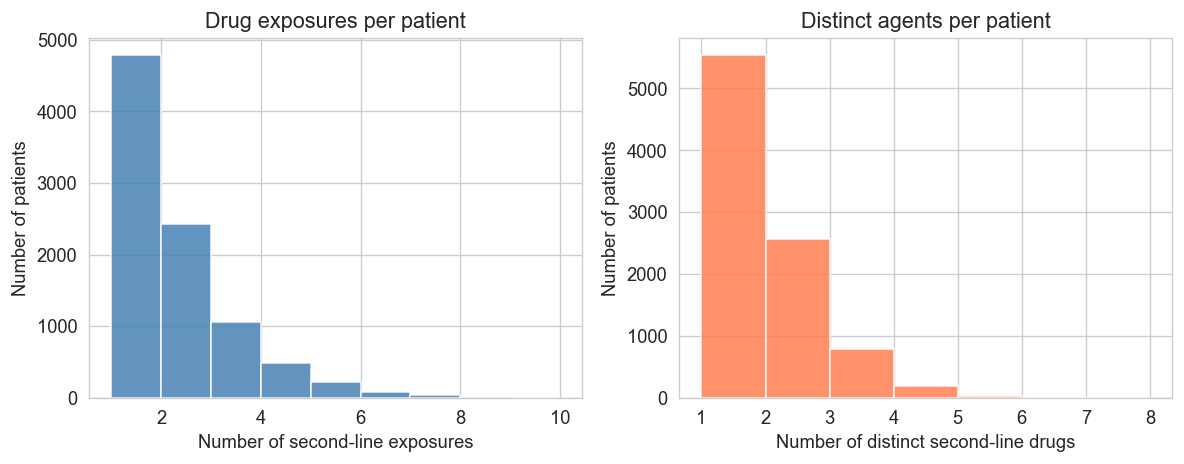

In [183]:
# Sort all exposures by patient and date
pathways = df_raw.sort_values(["person_id", "second_line_start_date"]).copy()

# Build ordered drug sequence per patient
patient_sequences = (
    pathways.groupby("person_id")["second_line_drug_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"second_line_drug_name": "drug_sequence"})
)

# Number of exposures per patient
patient_sequences["n_exposures"] = patient_sequences["drug_sequence"].apply(len)

# Number of distinct drugs per patient
patient_sequences["n_distinct_drugs"] = patient_sequences["drug_sequence"].apply(
    lambda x: len(set(x))
)

print("Exposures per patient:")
print(patient_sequences["n_exposures"].describe().round(1))
print()
print("Distinct second-line drugs per patient:")
print(patient_sequences["n_distinct_drugs"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
patient_sequences["n_exposures"].hist(
    ax=axes[0],
    bins=range(1, patient_sequences["n_exposures"].max() + 2),
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)
axes[0].set_xlabel("Number of second-line exposures")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Drug exposures per patient")

patient_sequences["n_distinct_drugs"].hist(
    ax=axes[1],
    bins=range(1, patient_sequences["n_distinct_drugs"].max() + 2),
    color="coral",
    edgecolor="white",
    alpha=0.85,
)
axes[1].set_xlabel("Number of distinct second-line drugs")
axes[1].set_ylabel("Number of patients")
axes[1].set_title("Distinct agents per patient")

plt.tight_layout()
plt.show()

### 4.2 Most Common Treatment Pathways

The top treatment pathways (ordered sequences of second-line drugs) observed in the cohort. Each pathway is read left to right as the temporal order of drugs received.

In [184]:
# Convert sequences to readable pathway strings

patient_sequences["pathway"] = patient_sequences["drug_sequence"].apply(
    lambda x: " → ".join(x)
)

# Top pathways
pathway_counts = patient_sequences["pathway"].value_counts().head(15)

print("Top 15 treatment pathways after metformin:")
print("=" * 65)
for i, (pathway, n) in enumerate(pathway_counts.items(), 1):
    pct = n / len(patient_sequences) * 100
    print(f"  {i:>2d}. [{n:>2d} pts, {pct:>4.1f}%]  metformin → {pathway}")

Top 15 treatment pathways after metformin:
   1. [2056 pts, 22.6%]  metformin → glyburide
   2. [1302 pts, 14.3%]  metformin → glipizide
   3. [460 pts,  5.0%]  metformin → rosiglitazone
   4. [394 pts,  4.3%]  metformin → glyburide → glyburide
   5. [360 pts,  3.9%]  metformin → glimepiride
   6. [351 pts,  3.9%]  metformin → pioglitazone
   7. [290 pts,  3.2%]  metformin → glyburide → glipizide
   8. [258 pts,  2.8%]  metformin → glipizide → glyburide
   9. [194 pts,  2.1%]  metformin → glipizide → glipizide
  10. [141 pts,  1.5%]  metformin → sitagliptin
  11. [120 pts,  1.3%]  metformin → rosiglitazone → glyburide
  12. [94 pts,  1.0%]  metformin → glyburide → rosiglitazone
  13. [90 pts,  1.0%]  metformin → rosiglitazone → glipizide
  14. [82 pts,  0.9%]  metformin → glyburide → glimepiride
  15. [72 pts,  0.8%]  metformin → glyburide → pioglitazone


### 4.3 State Transition Analysis

Which drugs do patients transition *between*? This matrix shows the count of observed transitions from one second-line drug to the next in the treatment sequence.

State transition matrix (from → to):
to_drug           glimepiride  glipizide  glyburide  insulin detemir  \
from_drug                                                              
glimepiride                62        205        200                0   
glipizide                 229        604        848                1   
glyburide                 282        876       1201                2   
insulin detemir             0          1          1                0   
insulin glargine            2         10          7                0   
nateglinide                 5         19         31                0   
pioglitazone               57        156        219                0   
repaglinide                 9         28         45                0   
rosiglitazone              83        256        357                2   
saxagliptin                 1          1          0                0   
sitagliptin                25         53         83                0   
All                       7

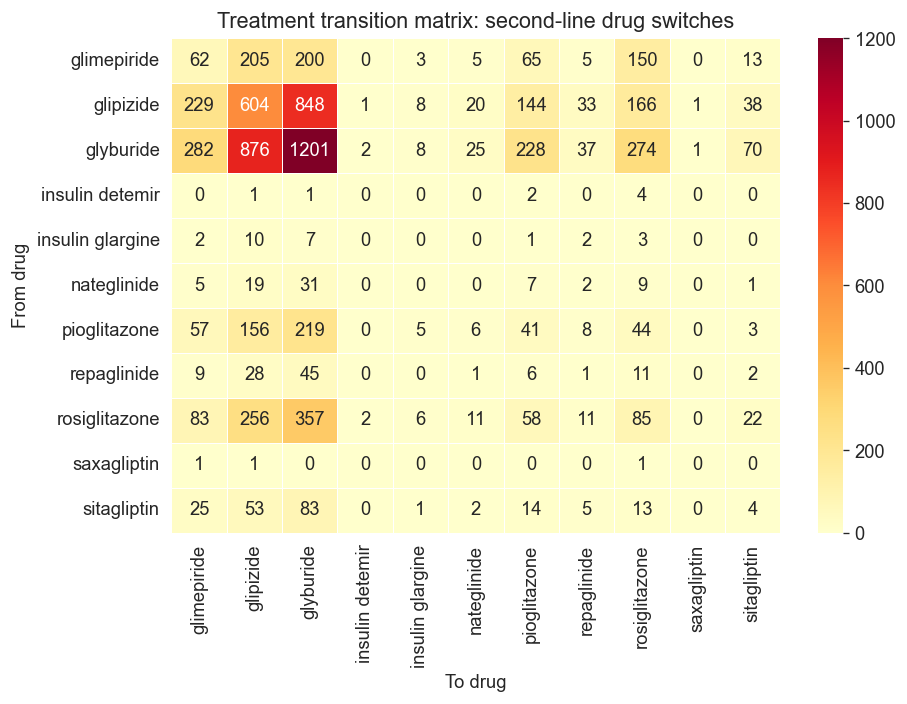


Top 10 most common transitions:
  glyburide → glyburide: 1201
  glyburide → glipizide: 876
  glipizide → glyburide: 848
  glipizide → glipizide: 604
  rosiglitazone → glyburide: 357
  glyburide → glimepiride: 282
  glyburide → rosiglitazone: 274
  rosiglitazone → glipizide: 256
  glipizide → glimepiride: 229
  glyburide → pioglitazone: 228


In [185]:
# Build transition pairs
transitions = []
for _, row in patient_sequences.iterrows():
    seq = row['drug_sequence']
    for i in range(len(seq) - 1):
        transitions.append((seq[i], seq[i+1]))

if len(transitions) > 0:
    trans_df = pd.DataFrame(transitions, columns=['from_drug', 'to_drug'])
    
    # Transition matrix
    trans_matrix = pd.crosstab(trans_df['from_drug'], trans_df['to_drug'], margins=True)
    print("State transition matrix (from → to):")
    print(trans_matrix)
    print()
    
    # Heatmap (without margins)
    trans_clean = pd.crosstab(trans_df['from_drug'], trans_df['to_drug'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(trans_clean, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('To drug')
    ax.set_ylabel('From drug')
    ax.set_title('Treatment transition matrix: second-line drug switches')
    plt.tight_layout()
    plt.show()
    
    # Most common transitions
    print("\nTop 10 most common transitions:")
    top_trans = trans_df.value_counts().head(10)
    for (fr, to), n in top_trans.items():
        print(f"  {fr} → {to}: {n}")
else:
    print("No transitions observed (all patients had only one second-line drug).")

### 4.4 Drug Class Grouping

Grouping individual drugs into pharmacologic classes to reveal higher-level treatment patterns.

First second-line agent by drug class:
----------------------------------------
  Sulfonylurea               n=6911  (75.8%)
  Thiazolidinedione          n=1701  (18.7%)
  DPP-4 inhibitor            n=272  (3.0%)
  Meglitinide                n=198  (2.2%)
  Other                      n= 34  (0.4%)


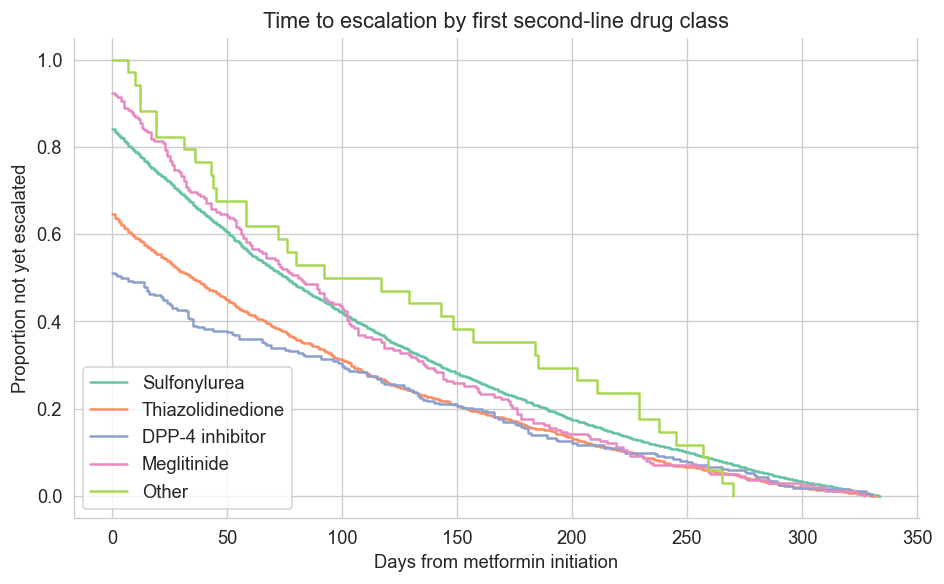

In [186]:
# Drug class mapping
drug_class_map = {
    'glyburide': 'Sulfonylurea',
    'glipizide': 'Sulfonylurea',
    'glimepiride': 'Sulfonylurea',
    'pioglitazone': 'Thiazolidinedione',
    'rosiglitazone': 'Thiazolidinedione',
    'sitagliptin': 'DPP-4 inhibitor',
    'nateglinide': 'Meglitinide',
    'repaglinide': 'Meglitinide',
}

# Map first drug to class
df['first_drug_class'] = df['second_line_drug_name'].map(drug_class_map).fillna('Other')

# Class distribution
class_counts = df['first_drug_class'].value_counts()
print("First second-line agent by drug class:")
print("-" * 40)
for cls, n in class_counts.items():
    print(f"  {cls:<25s}  n={n:>3d}  ({n/len(df)*100:.1f}%)")

# KM by drug class
fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()
palette = sns.color_palette("Set2", len(class_counts))

for i, cls in enumerate(class_counts.index):
    mask = df['first_drug_class'] == cls
    if mask.sum() >= 2:
        kmf.fit(df.loc[mask, 'time_to_escalation'],
                event_observed=df.loc[mask, 'event'],
                label=cls)
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])

ax.set_xlabel('Days from metformin initiation')
ax.set_ylabel('Proportion not yet escalated')
ax.set_title('Time to escalation by first second-line drug class')
ax.legend(loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Study Limitations and Methodological Notes

1. **Selection bias:** This dataset includes only patients who were escalated to a second-line agent. Patients who remained on metformin monotherapy throughout the observation period are excluded. All survival analyses therefore describe the *distribution of escalation timing among those who escalated*, not the overall probability of escalation.

2. **No censoring:** Because all patients in the dataset experienced the event, there are no censored observations. The KM estimator reduces to the empirical CDF, and the Cox model estimates relative differences in escalation speed without the usual censoring adjustments.

3. **Small sample size:** With ~50 unique patients, statistical power is limited. Confidence intervals on hazard ratios are wide, stratified analyses have very small cell sizes, and proportional hazards tests have low power. Results should be interpreted as exploratory.

4. **Unmeasured confounders:** Key clinical variables — HbA1c, BMI, renal function (eGFR), diabetes duration — are not available in this dataset. Prescriber behavior and clinical inertia are also unmeasured. As discussed in the DAG, disease severity is the most important unmeasured confounder.

5. **Observation intensity bias:** Patients with more healthcare encounters have more opportunities for escalation to be documented. Healthcare utilization is not available as a covariate in this extract.

6. **Temporal context:** The cohort start dates cluster around January 2009, which precedes the widespread adoption of SGLT2 inhibitors and GLP-1 receptor agonists. The treatment landscape reflected here is historically specific.

7. **Outcome definition:** The distinction between add-on therapy and drug switching is not explicitly modeled. Both are captured as "second-line initiation."